# 💰 Cartly — Product & Revenue Analysis

---

## 🎯 What We Want to Answer

Now we shift from *how users behave* to *what makes money*. This notebook focuses on the **revenue engine** of Cartly.

Key questions:

1. **Which products and categories generate the most revenue?**
2. **Which products are most viewed but least purchased?** (missed conversion opportunity)
3. **How has revenue trended over time?**
4. **Who are our top customers?**
5. **What is the average order value and discount impact?**

This analysis helps the product and marketing teams decide **where to focus their energy**.

---

## 🔧 Step 1 — Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Load data
products     = pd.read_csv('../data/products.csv',     parse_dates=['created_date'])
transactions = pd.read_csv('../data/transactions.csv', parse_dates=['purchase_date'])
events       = pd.read_csv('../data/events.csv',       parse_dates=['event_time'])
users        = pd.read_csv('../data/users.csv')

# Keep only successful transactions
txn = transactions[transactions['order_status'] == 'Success'].copy()
print(f'Total transactions : {len(transactions):,}')
print(f'Successful only    : {len(txn):,}')
print(f'Total revenue      : ₹{txn["amount"].sum():,.0f}')

Total transactions : 30,000
Successful only    : 26,935
Total revenue      : ₹78,755,750


## 🔗 Step 2 — Enrich Transactions with Product Info

We join the transactions table with the products table to get category and product name information.

In [2]:
# Merge transactions with product details
txn = txn.merge(products[['product_id', 'product_name', 'category', 'sub_category', 'price', 'rating']],
                on='product_id', how='left')

# Add time columns
txn['purchase_month'] = txn['purchase_date'].dt.to_period('M')
txn['purchase_week']  = txn['purchase_date'].dt.to_period('W')
txn['day_of_week']    = txn['purchase_date'].dt.day_name()

print('Merged dataset shape:', txn.shape)
txn[['product_id', 'product_name', 'category', 'amount', 'discount_amount']].head()

Merged dataset shape: (26935, 17)


,product_id,product_name,category,amount,discount_amount
0,P0013,Email Marketing Pro,Course,1760.0,440.0
1,P0071,Color Theory Guide,Ebook,800.0,0.0
2,P0069,Brand Story eBook 69,Ebook,1620.0,180.0
3,P0072,UX Laws eBook,Ebook,810.0,90.0
4,P0127,P&L Statement Template 127,Template,950.0,50.0


---
## 📈 Step 3 — Revenue Over Time

Before diving into products, we look at the **overall revenue trend** to understand if the business is growing, flat, or declining.

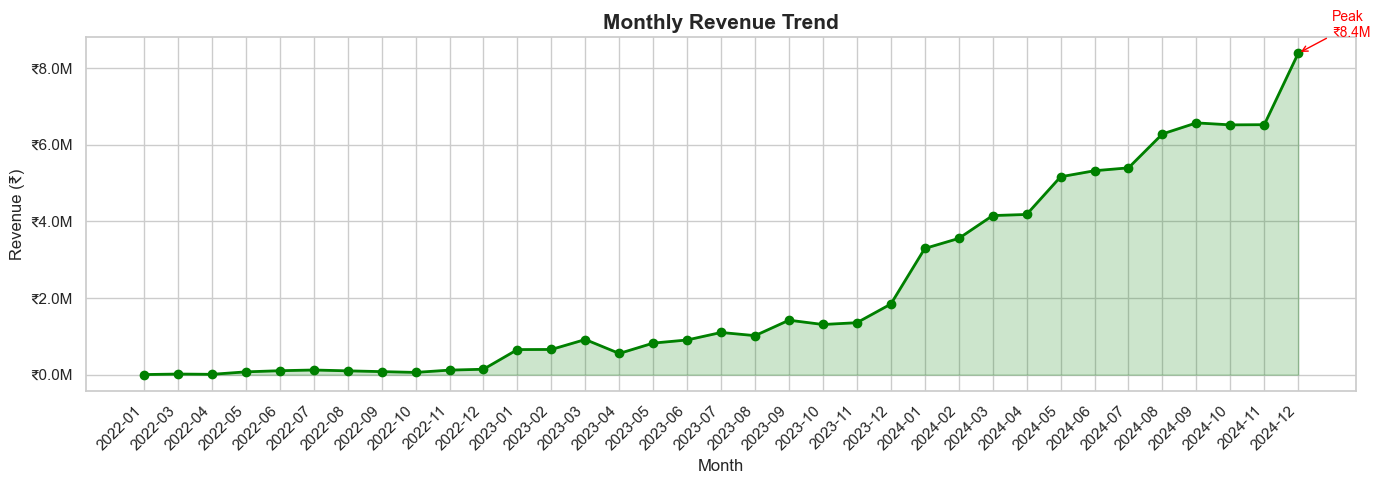

In [3]:
monthly_revenue = (
    txn
    .groupby('purchase_month')['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'revenue'})
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'],
                alpha=0.2, color='green')
ax.plot(range(len(monthly_revenue)), monthly_revenue['revenue'],
        marker='o', color='green', linewidth=2)

ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['purchase_month'].astype(str), rotation=45, ha='right')
ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

# Add peak annotation
peak_idx = monthly_revenue['revenue'].idxmax()
ax.annotate(f'Peak\n₹{monthly_revenue.loc[peak_idx, "revenue"]/1e6:.1f}M',
            xy=(peak_idx, monthly_revenue.loc[peak_idx, 'revenue']),
            xytext=(peak_idx + 1, monthly_revenue.loc[peak_idx, 'revenue'] * 1.05),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\Report\\03_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Revenue Trend

> **Identify the peak month** — what caused it? A sale? A new product launch? A viral moment? If you can repeat those conditions, you can reliably create revenue spikes.
>
> **Look for seasonal patterns** — digital product businesses often spike at year-end (New Year resolutions, holiday gifts) and back-to-school periods.

---
## 🏆 Step 4 — Top Categories by Revenue

Which product categories are the real revenue drivers for Cartly?

In [4]:
category_revenue = (
    txn
    .groupby('category')
    .agg(
        total_revenue  = ('amount', 'sum'),
        total_orders   = ('transaction_id', 'count'),
        avg_order_value = ('amount', 'mean')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

category_revenue['revenue_share_pct'] = (
    category_revenue['total_revenue'] / category_revenue['total_revenue'].sum() * 100
).round(1)

print(category_revenue.to_string(index=False))

     category  total_revenue  total_orders  avg_order_value  revenue_share_pct
       Course     43679930.0          7346          5946.08               55.5
Software Tool     22599615.0          6748          3349.08               28.7
     Template      8131925.0          5631          1444.14               10.3
        Ebook      4344280.0          7210           602.54                5.5


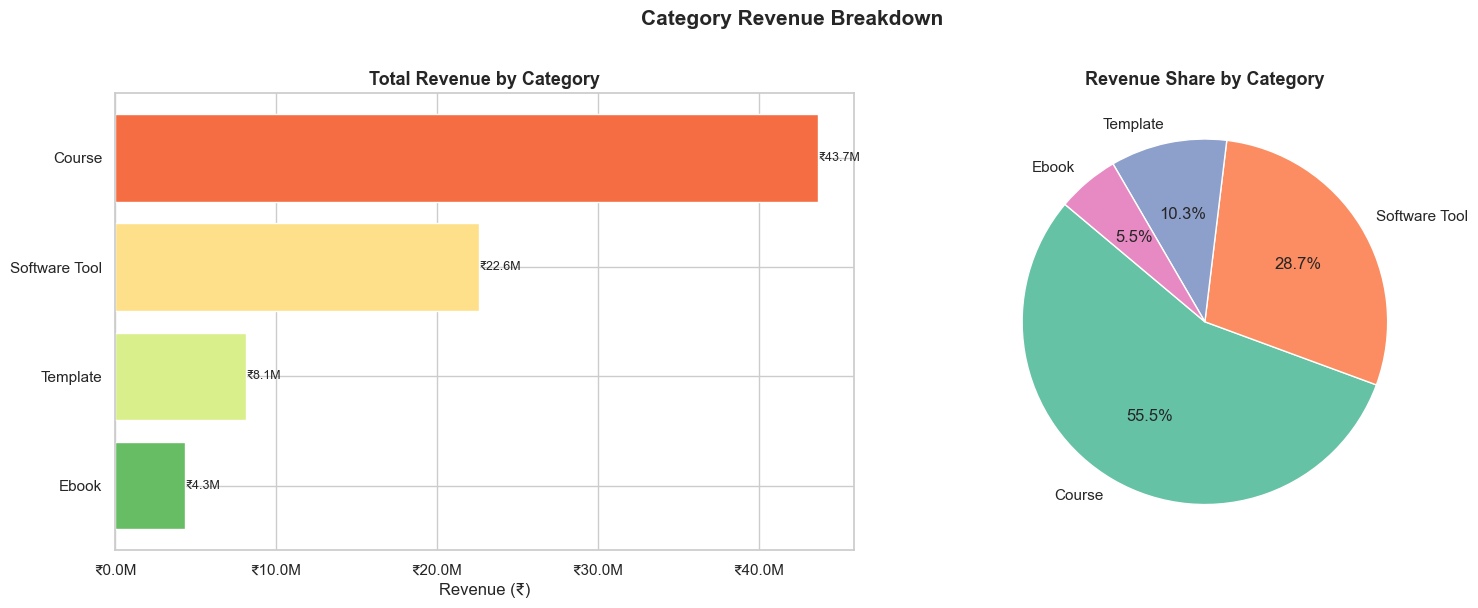

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by category — horizontal bar
palette = sns.color_palette('RdYlGn', len(category_revenue))
bars = axes[0].barh(
    category_revenue['category'][::-1],
    category_revenue['total_revenue'][::-1],
    color=palette[::-1]
)
axes[0].set_title('Total Revenue by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
for bar in bars:
    axes[0].text(bar.get_width() + 5000, bar.get_y() + bar.get_height() / 2,
                 f'₹{bar.get_width()/1e6:.1f}M', va='center', fontsize=9)

# Revenue share pie
axes[1].pie(
    category_revenue['revenue_share_pct'],
    labels=category_revenue['category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(category_revenue))
)
axes[1].set_title('Revenue Share by Category', fontsize=13, fontweight='bold')

plt.suptitle('Category Revenue Breakdown', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\03_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Category Revenue

> **The top 2-3 categories likely contribute 60-70% of total revenue** — this is the Pareto Principle in action. Focus product development and marketing budgets on these categories.
>
> **Low-revenue categories aren't failures** — they might be newer segments or niche audiences with high growth potential. Analyse their avg order value before discontinuing.

---
## 🛒 Step 5 — Top 10 Products by Revenue

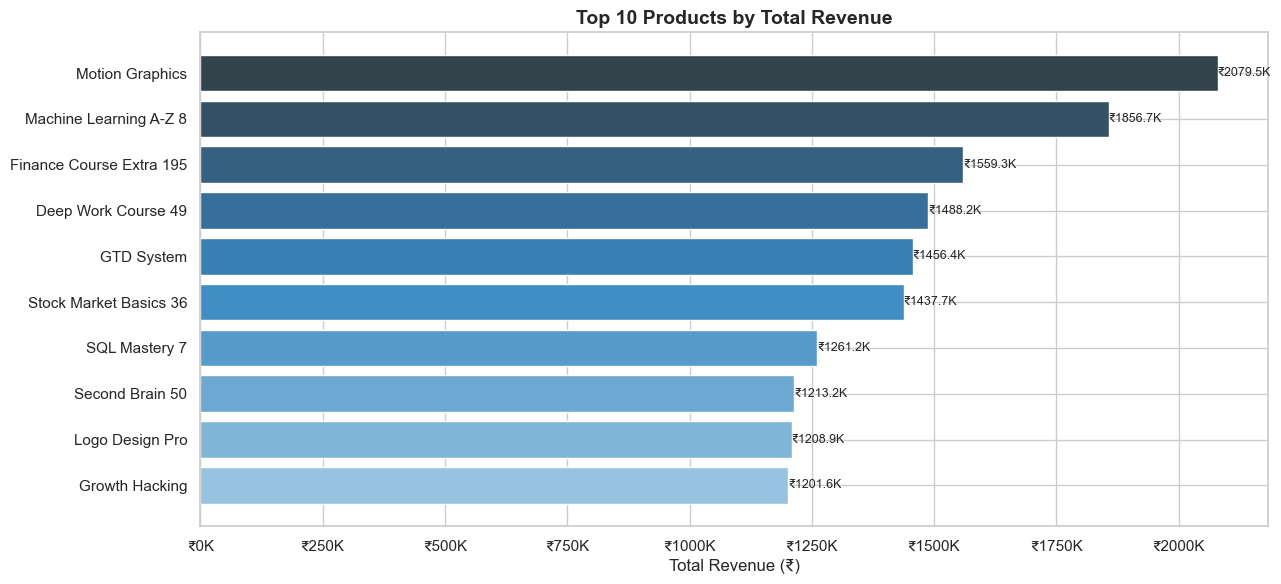

In [6]:
top_products = (
    txn
    .groupby(['product_id', 'product_name', 'category'])
    .agg(
        total_revenue = ('amount', 'sum'),
        total_orders  = ('transaction_id', 'count')
    )
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))

colors = sns.color_palette('Blues_d', len(top_products))
bars = ax.barh(
    top_products['product_name'][::-1],
    top_products['total_revenue'][::-1],
    color=colors
)

ax.set_title('Top 10 Products by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))

for bar in bars:
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f'₹{bar.get_width()/1e3:.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\03_top_products_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 👁️ Step 6 — Most Viewed vs Most Purchased Products

This is a **critical analysis**. Products with many views but few purchases point to a breakdown in trust, pricing, or the product description. These are your biggest conversion opportunities.

In [7]:
# Product clicks from events
product_views = (
    events[events['event_type'] == 'product_click']
    .groupby('product_id')
    .size()
    .reset_index(name='view_count')
)
# Clean product_id type
product_views['product_id'] = product_views['product_id'].astype(str).str.replace('.0', '', regex=False)

# Purchase counts per product
product_purchases = (
    txn
    .groupby('product_id')
    .size()
    .reset_index(name='purchase_count')
)

# Merge with product names
view_vs_buy = product_views.merge(product_purchases, on='product_id', how='left').fillna(0)
view_vs_buy = view_vs_buy.merge(products[['product_id', 'product_name', 'category']], on='product_id', how='left')

# View-to-purchase conversion rate
view_vs_buy['conversion_rate'] = (view_vs_buy['purchase_count'] / view_vs_buy['view_count'] * 100).round(2)
view_vs_buy = view_vs_buy.sort_values('view_count', ascending=False)

print('Top 10 Most Viewed Products:')
print(view_vs_buy[['product_name', 'view_count', 'purchase_count', 'conversion_rate']].head(10).to_string(index=False))

Top 10 Most Viewed Products:
           product_name  view_count  purchase_count  conversion_rate
  Morning Routine eBook         210             154            73.33
   Invoice Template 119         209             125            59.81
       Tax Saving Guide         207             124            59.90
   Copywriting Bible 70         206             162            78.64
Email Campaign Template         206             139            67.48
  Task Manager Tool 187         204             170            83.33
   Report Generator 149         203             125            61.58
    Stock Market Basics         203             111            54.68
 Viral Content Guide 68         202             125            61.88
     Weekly Planner 137         201             144            71.64


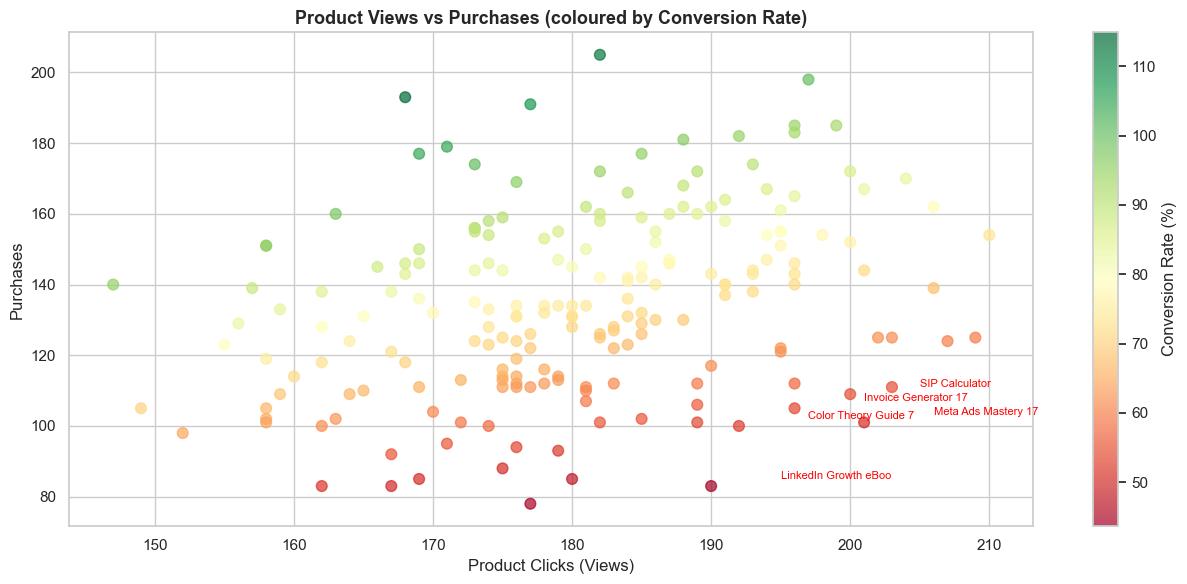

In [8]:
# Products with high views but low conversion = biggest opportunity
high_views = view_vs_buy[view_vs_buy['view_count'] >= view_vs_buy['view_count'].quantile(0.75)]
opportunity = high_views.sort_values('conversion_rate').head(10)

fig, ax = plt.subplots(figsize=(13, 6))

# Scatter: views vs purchases
scatter = ax.scatter(
    view_vs_buy['view_count'],
    view_vs_buy['purchase_count'],
    c=view_vs_buy['conversion_rate'],
    cmap='RdYlGn',
    s=60,
    alpha=0.7
)
plt.colorbar(scatter, ax=ax, label='Conversion Rate (%)')

ax.set_title('Product Views vs Purchases (coloured by Conversion Rate)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Product Clicks (Views)')
ax.set_ylabel('Purchases')

# Annotate top opportunities
for _, row in opportunity.head(5).iterrows():
    ax.annotate(str(row['product_name'])[:20],
                xy=(row['view_count'], row['purchase_count']),
                xytext=(row['view_count'] + 5, row['purchase_count'] + 2),
                fontsize=8, color='red')

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\03_views_vs_purchases.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Views vs Purchases

> **Products in the bottom-left (low views, low purchases) may simply have discoverability issues** — better search rankings, tags, or featuring them on the homepage could boost both metrics.
>
> **Products with HIGH views but LOW conversion are the biggest revenue opportunity** — users are interested but something stops them from buying. Common causes:
> - Price too high relative to perceived value
> - Poor product description or no demo/preview
> - Lack of social proof (reviews, ratings)
> - Complex or untrustworthy checkout

---
## 👑 Step 7 — Top Customers by Lifetime Value

**Customer Lifetime Value (CLV)** identifies your most valuable customers. Retaining them is 5x cheaper than acquiring new ones.

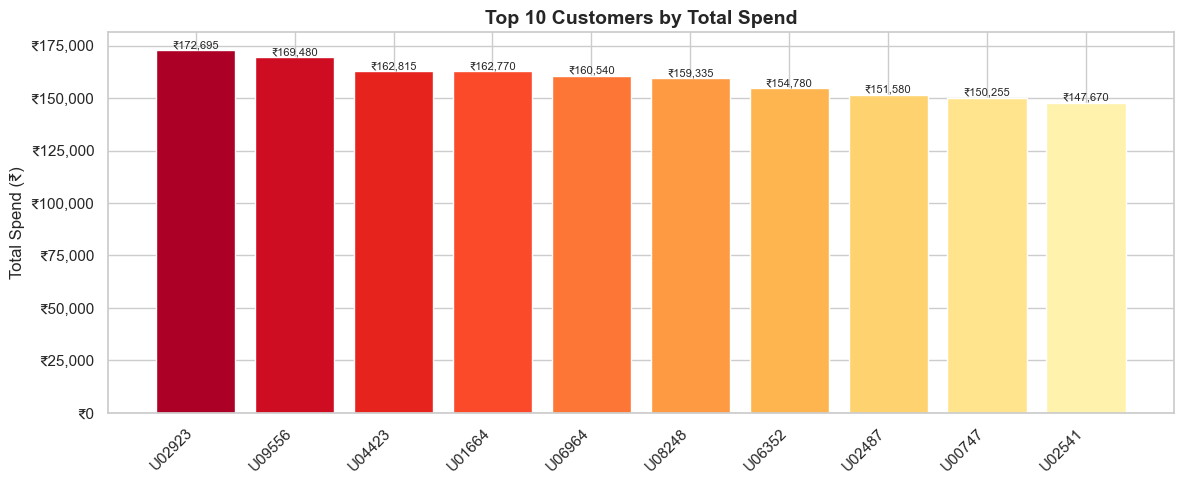

Top 10 customers contribute: ₹1,591,920
That's 2.0% of total revenue


In [9]:
customer_ltv = (
    txn
    .groupby('user_id')
    .agg(
        total_spend    = ('amount', 'sum'),
        total_orders   = ('transaction_id', 'count'),
        avg_order_val  = ('amount', 'mean'),
        first_purchase = ('purchase_date', 'min'),
        last_purchase  = ('purchase_date', 'max')
    )
    .sort_values('total_spend', ascending=False)
    .reset_index()
)

# Top 10 customers
top_customers = customer_ltv.head(10)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(range(10), top_customers['total_spend'],
              color=sns.color_palette('YlOrRd_r', 10))
ax.set_xticks(range(10))
ax.set_xticklabels(top_customers['user_id'], rotation=45, ha='right')
ax.set_title('Top 10 Customers by Total Spend', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Spend (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'₹{bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\03_top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 10 customers contribute: ₹{top_customers['total_spend'].sum():,.0f}")
print(f"That's {top_customers['total_spend'].sum() / txn['amount'].sum() * 100:.1f}% of total revenue")

### 💡 Business Insight — Top Customers

> **A small segment of customers drives a disproportionate share of revenue** — this is typical (Pareto: 20% of customers = 80% of revenue). These users deserve a **VIP loyalty program**, early access to new products, and personalised recommendations.
>
> **Customers with many orders but lower spend could be upsell opportunities** — they trust Cartly but haven't discovered premium products yet.

---
## 💸 Step 8 — Discount Impact on Revenue

In [10]:
total_gross    = (txn['amount'] + txn['discount_amount']).sum()
total_discount = txn['discount_amount'].sum()
total_net      = txn['amount'].sum()
discount_pct   = total_discount / total_gross * 100

print(f'Gross Revenue (before discount) : ₹{total_gross:>12,.0f}')
print(f'Total Discounts Given           : ₹{total_discount:>12,.0f}')
print(f'Net Revenue (after discount)    : ₹{total_net:>12,.0f}')
print(f'Discount Rate                   :  {discount_pct:>10.1f}%')

Gross Revenue (before discount) : ₹  86,590,300
Total Discounts Given           : ₹   7,834,550
Net Revenue (after discount)    : ₹  78,755,750
Discount Rate                   :         9.0%


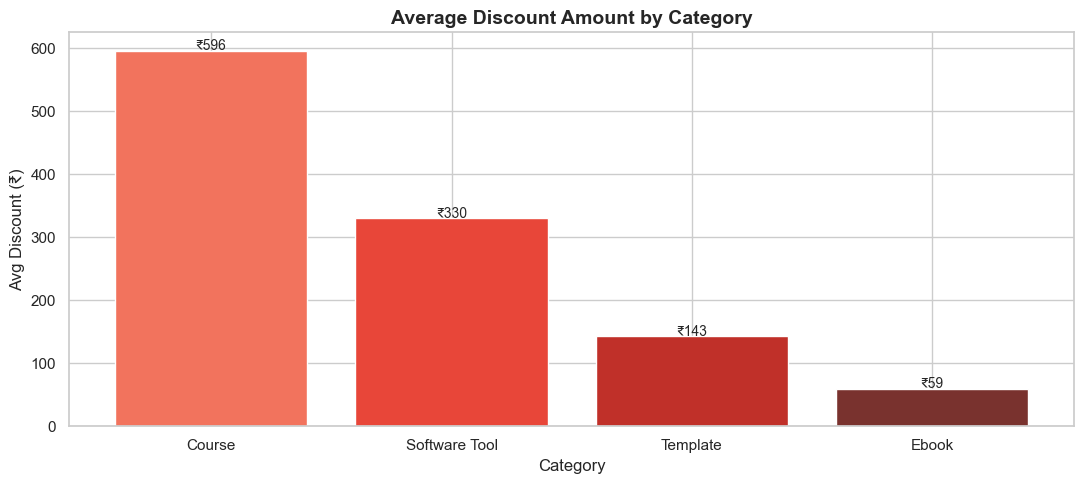

In [11]:
# Discount by category
discount_by_cat = (
    txn
    .groupby('category')
    .agg(avg_discount=('discount_amount', 'mean'))
    .sort_values('avg_discount', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(discount_by_cat['category'], discount_by_cat['avg_discount'],
       color=sns.color_palette('Reds_d', len(discount_by_cat)))
ax.set_title('Average Discount Amount by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Avg Discount (₹)')
for i, v in enumerate(discount_by_cat['avg_discount']):
    ax.text(i, v + 1, f'₹{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\03_discounts.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Discounts

> **Heavy discounting hurts margins** — if a category consistently shows high discount amounts, it may indicate that the list price is too high (customers only buy on sale) or that there's competitive pressure in that space.
>
> **Strategic discounting works** — targeted discounts to specific user segments (e.g., cart abandoners, first-time buyers) convert better than blanket promotions.

---
## ✅ Summary — Revenue Health Check

| Metric | Value |
|--------|-------|
| Total Net Revenue | ₹X.XXM |
| Avg Monthly Revenue | ₹X.XXM |
| Top Revenue Category | TBD from analysis |
| Discount Rate | ~X% |
| Revenue from Top 10 Customers | ~X% |

### 🔑 Key Recommendations

1. **Fix high-view, low-conversion products** — write better descriptions, add preview content, collect reviews.
2. **Launch a VIP program** for top customers — retain them with exclusive perks.
3. **Review discount strategy** — move from blanket discounts to personalised, targeted offers.
4. **Invest in top-performing categories** — they have proven demand and should receive more products.

---